# Part 1 - CNN Architectures (RGB)

Experiment with 4 CNN architectures of increasing complexity on RGB patches.  
Each architecture has >= 10x the parameters of its predecessor.

**Requirements:**
- At least 4 architectures, first simple, each successive >= 10x params
- All trained >= 50 epochs with early stopping (patience=10)
- Generate model summaries
- ONE figure with 4 plots: params (log x) vs train/val accuracy & F1
- Identify optimal architecture

In [1]:
import torch
from torchinfo import summary
from models import build_cnn, verify_10x_rule
from training import get_dataloaders, train_model
from analysis import plot_4panel, plot_training_curves, print_results_table

MANIFEST = "manifests/rgb_manifest.csv"
MODALITY = "RGB"
BATCH_SIZE = 256
EPOCHS = 70  # max epochs (early stop after 50 with patience 10)
LR = 1e-3
MIN_EPOCHS = 50
PATIENCE = 10

print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Device: NVIDIA GeForce RTX 5090


## 1. Verify Parameter Growth Rule

In [2]:
param_counts = verify_10x_rule()

  Arch A:        880 params
  Arch B:     14,600 params
  Arch C:    148,200 params
  Arch D:  2,459,848 params
  B/A ratio: 16.6x [PASS]
  C/B ratio: 10.2x [PASS]
  D/C ratio: 16.6x [PASS]


## 2. Model Summaries

In [3]:
for arch in ["A", "B", "C", "D"]:
    model, count = build_cnn(arch)
    print(f"\n{'='*60}")
    print(f"Architecture {arch}: {count:,} parameters")
    print(f"{'='*60}")
    summary(model, input_size=(1, 3, 64, 64), verbose=1)
    del model


Architecture A: 880 parameters
Layer (type:depth-idx)                   Output Shape              Param #
CNNArchA                                 [1, 8]                    --
├─Sequential: 1-1                        [1, 8, 32, 32]            --
│    └─Sequential: 2-1                   [1, 8, 64, 64]            --
│    │    └─Conv2d: 3-1                  [1, 8, 64, 64]            224
│    │    └─ReLU: 3-2                    [1, 8, 64, 64]            --
│    └─MaxPool2d: 2-2                    [1, 8, 32, 32]            --
│    └─Sequential: 2-3                   [1, 8, 32, 32]            --
│    │    └─Conv2d: 3-3                  [1, 8, 32, 32]            584
│    │    └─ReLU: 3-4                    [1, 8, 32, 32]            --
├─AdaptiveAvgPool2d: 1-2                 [1, 8, 1, 1]              --
├─Linear: 1-3                            [1, 8]                    72
Total params: 880
Trainable params: 880
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.52
Input size (MB): 

## 3. Load Data

In [4]:
train_loader, val_loader, train_df, val_df = get_dataloaders(
    MANIFEST, batch_size=BATCH_SIZE, num_workers=4
)
print(f"Train: {len(train_loader.dataset):,} samples ({len(train_loader)} batches)")
print(f"Val:   {len(val_loader.dataset):,} samples ({len(val_loader)} batches)")

Windows detected: forcing num_workers=0 to avoid duplicate worker launches.
Train: 92,161 samples (361 batches)
Val:   16,136 samples (64 batches)


## 4. Train All 4 Architectures

In [5]:
results = []
histories = {}

for arch in ["A", "B", "C", "D"]:
    print(f"\n{'#'*60}")
    print(f"# Training Architecture {arch} ({param_counts[arch]:,} params)")
    print(f"{'#'*60}")

    model, count = build_cnn(arch)
    history = train_model(
        model, train_loader, val_loader,
        epochs=EPOCHS, lr=LR,
        patience=PATIENCE, min_epochs=MIN_EPOCHS,
        checkpoint_name=f"part1_rgb_arch{arch}"
    )
    histories[arch] = history

    results.append({
        "label": f"Arch {arch}",
        "arch": arch,
        "param_count": count,
        "best_epoch": history["best_epoch"],
        "best_train_acc": history["best_train_acc"],
        "best_val_acc": history["best_val_acc"],
        "best_train_f1": history["best_train_f1"],
        "best_val_f1": history["best_val_f1"],
    })

    del model
    torch.cuda.empty_cache()


############################################################
# Training Architecture A (880 params)
############################################################
  Epoch   1/70 | Loss: 1.5105/1.4874 | Acc: 0.4896/0.5025 | F1: 0.3385/0.3361 | LR: 1.00e-03
  Epoch   5/70 | Loss: 1.3855/1.4657 | Acc: 0.5030/0.5025 | F1: 0.3366/0.3361 | LR: 1.00e-03
  Epoch  10/70 | Loss: 1.2987/1.4091 | Acc: 0.5251/0.5053 | F1: 0.3791/0.3430 | LR: 1.00e-03
  Epoch  15/70 | Loss: 1.2165/1.3096 | Acc: 0.5653/0.5230 | F1: 0.4729/0.3841 | LR: 1.00e-03
  Epoch  20/70 | Loss: 1.1411/1.3113 | Acc: 0.6102/0.5107 | F1: 0.5472/0.4645 | LR: 1.00e-03
  Epoch  25/70 | Loss: 1.1169/1.2879 | Acc: 0.6199/0.5500 | F1: 0.5613/0.4413 | LR: 5.00e-04
  Epoch  30/70 | Loss: 1.1017/1.2468 | Acc: 0.6231/0.5578 | F1: 0.5660/0.5011 | LR: 5.00e-04
  Epoch  35/70 | Loss: 1.0935/1.2028 | Acc: 0.6272/0.5938 | F1: 0.5707/0.5280 | LR: 2.50e-04
  Epoch  40/70 | Loss: 1.0889/1.1974 | Acc: 0.6291/0.6004 | F1: 0.5732/0.5318 | LR: 1.25e-04
 

## 5. Results Summary

In [6]:
print_results_table(results)

Label                    Params  Best Ep  Train Acc    Val Acc   Train F1     Val F1
------------------------------------------------------------------------------------
Arch A                      880       24     0.6249     0.5988     0.5785     0.5384
Arch B                   14,600       64     0.8393     0.7959     0.8230     0.7665
Arch C                  148,200       70     0.9468     0.8909     0.9453     0.8857
Arch D                2,459,848       39     0.9999     0.9201     0.9999     0.9185


## 6. Required 4-Panel Figure

  Saved: c:\Users\Tonito\.vscode\Final-Exam-CSE-547\figures\part1_rgb_architectures.png


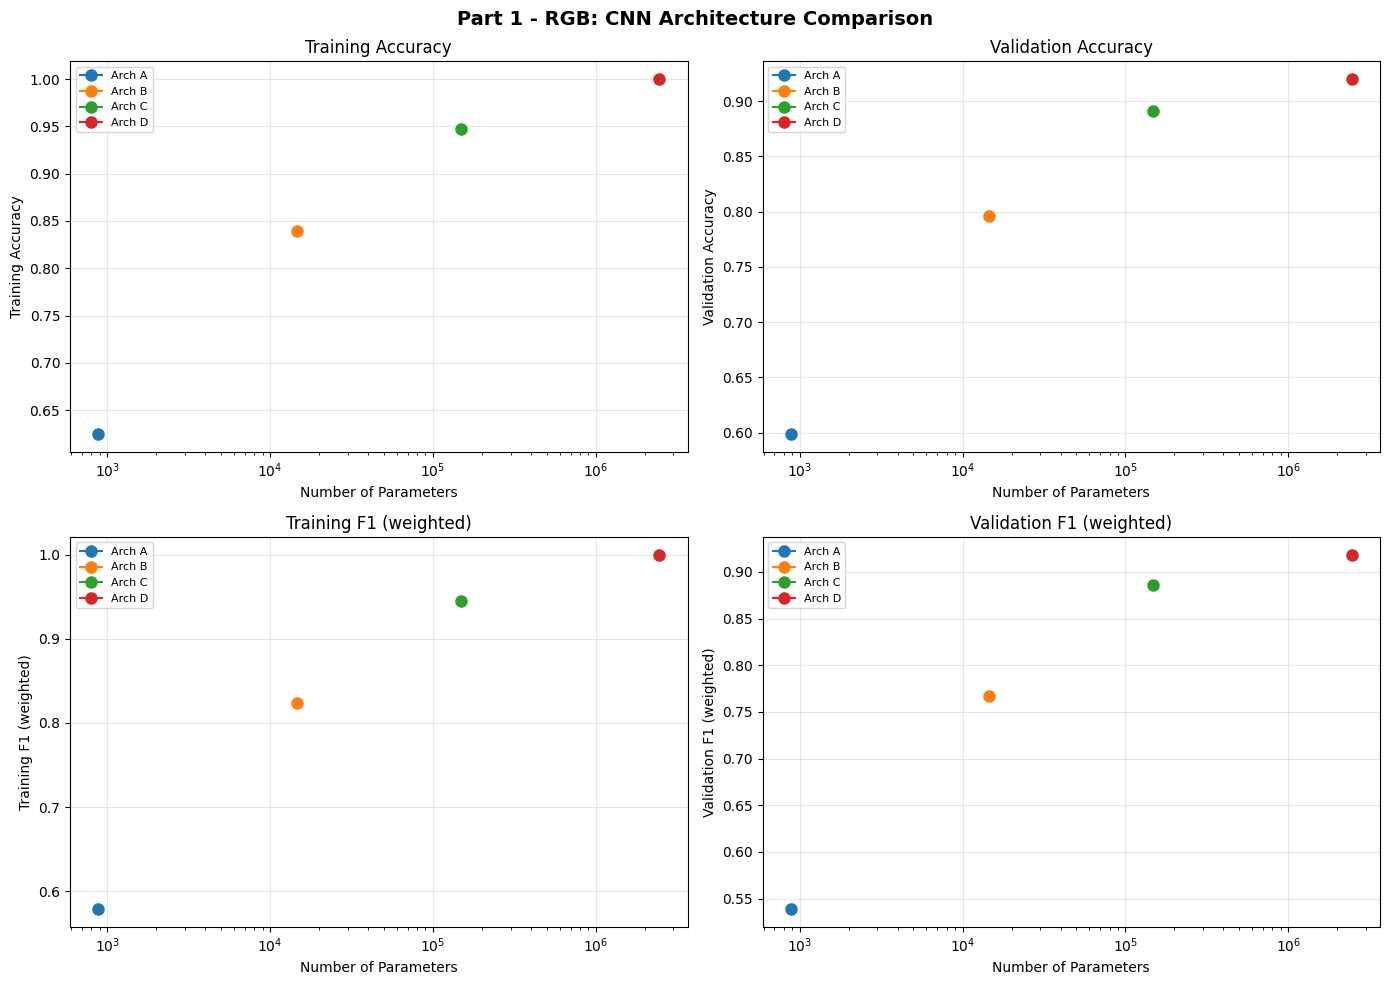

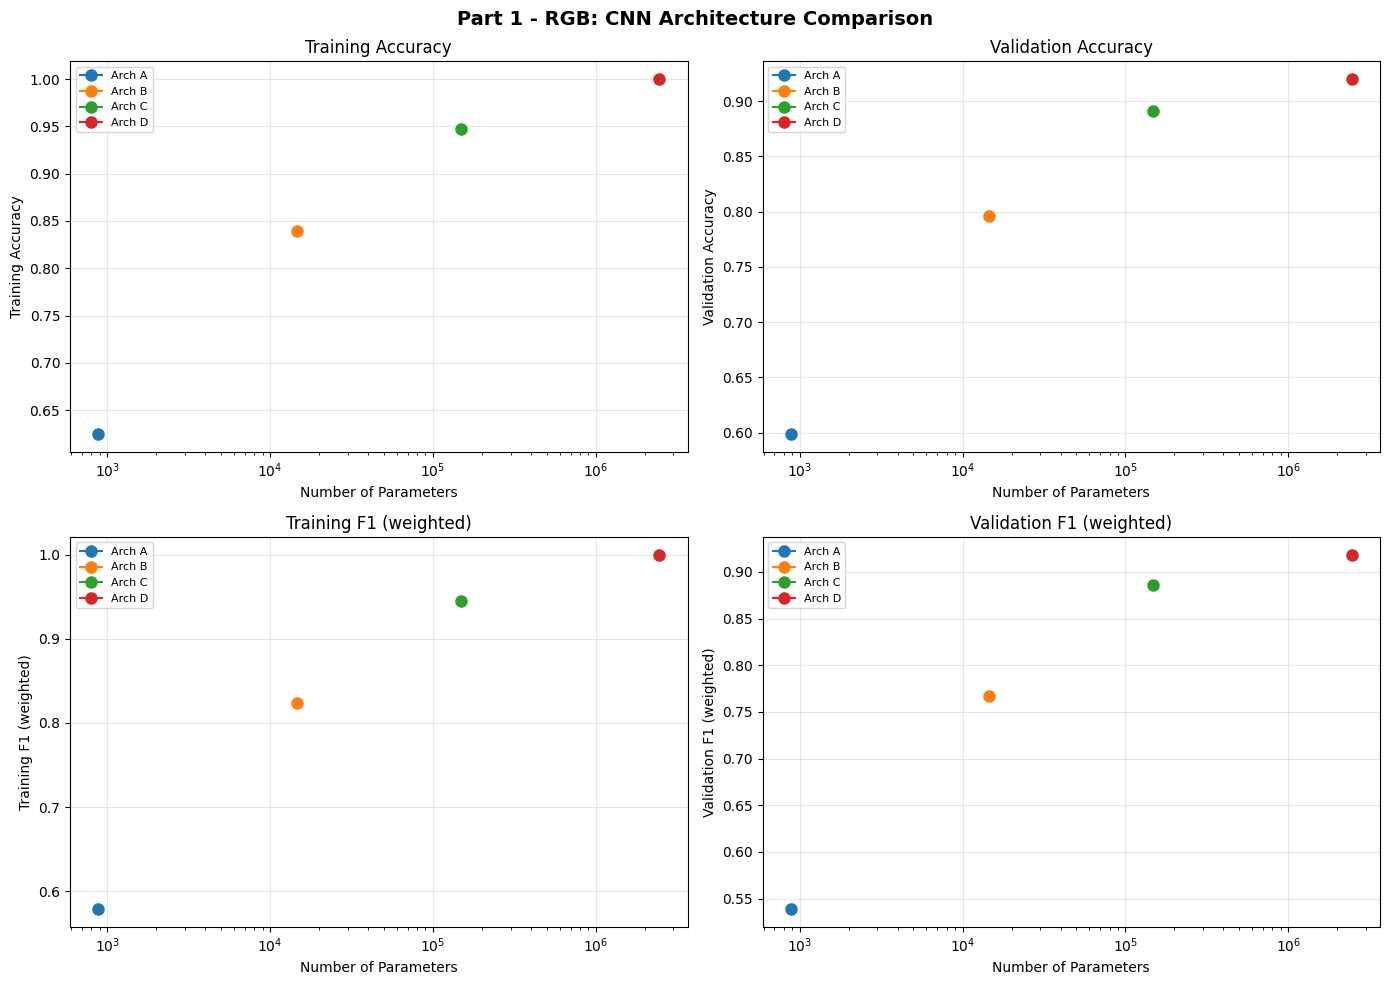

In [7]:
x_values = [r["param_count"] for r in results]

plot_4panel(
    results, x_values,
    x_label="Number of Parameters",
    title=f"Part 1 - {MODALITY}: CNN Architecture Comparison",
    x_log=True,
    save_name=f"part1_{MODALITY.lower()}_architectures.png"
)

## 7. Individual Training Curves

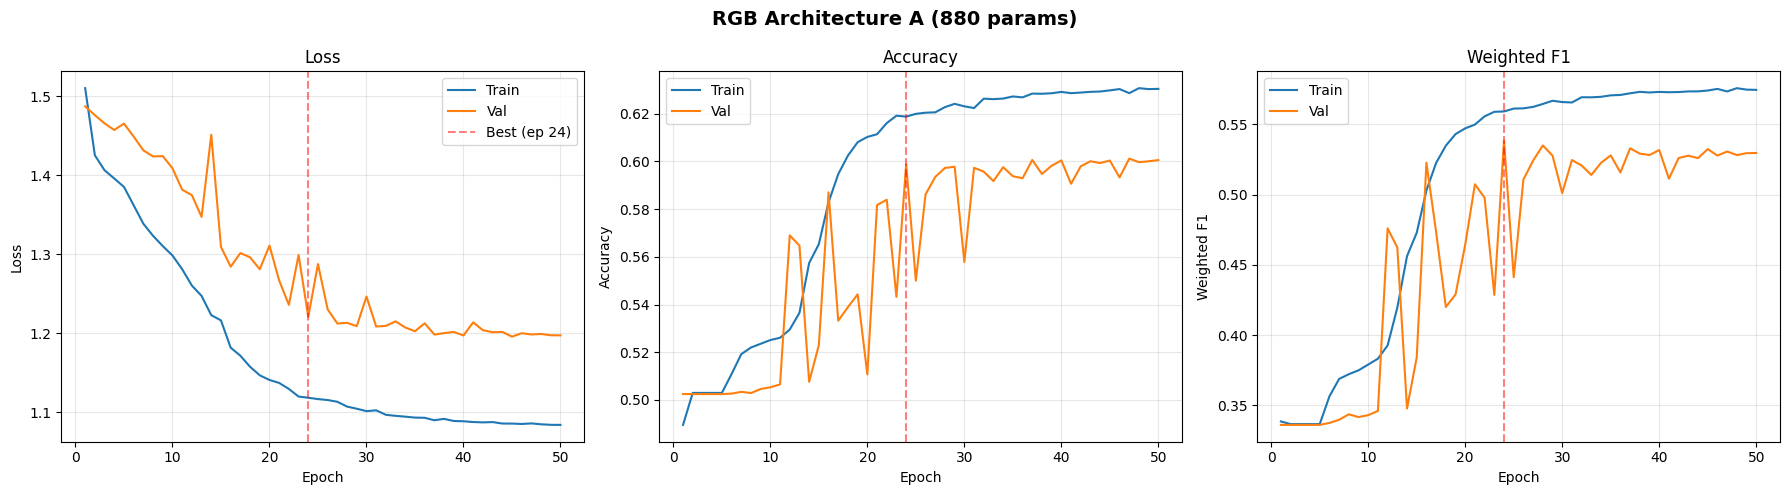

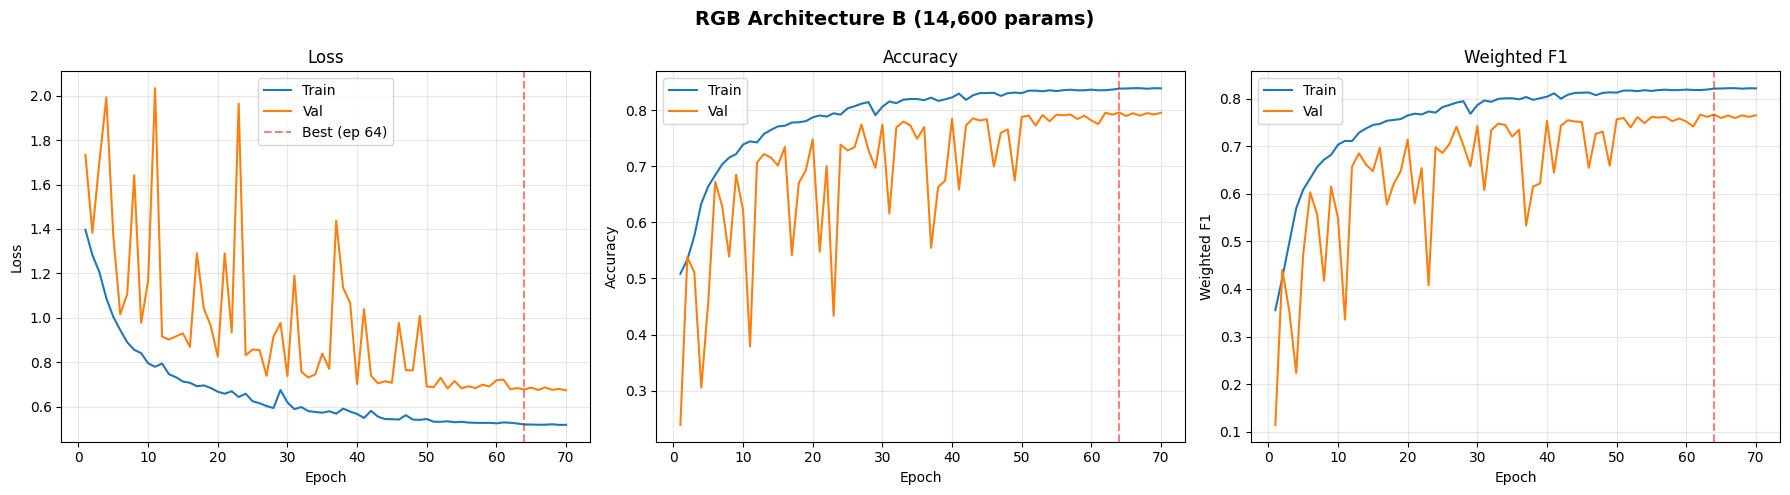

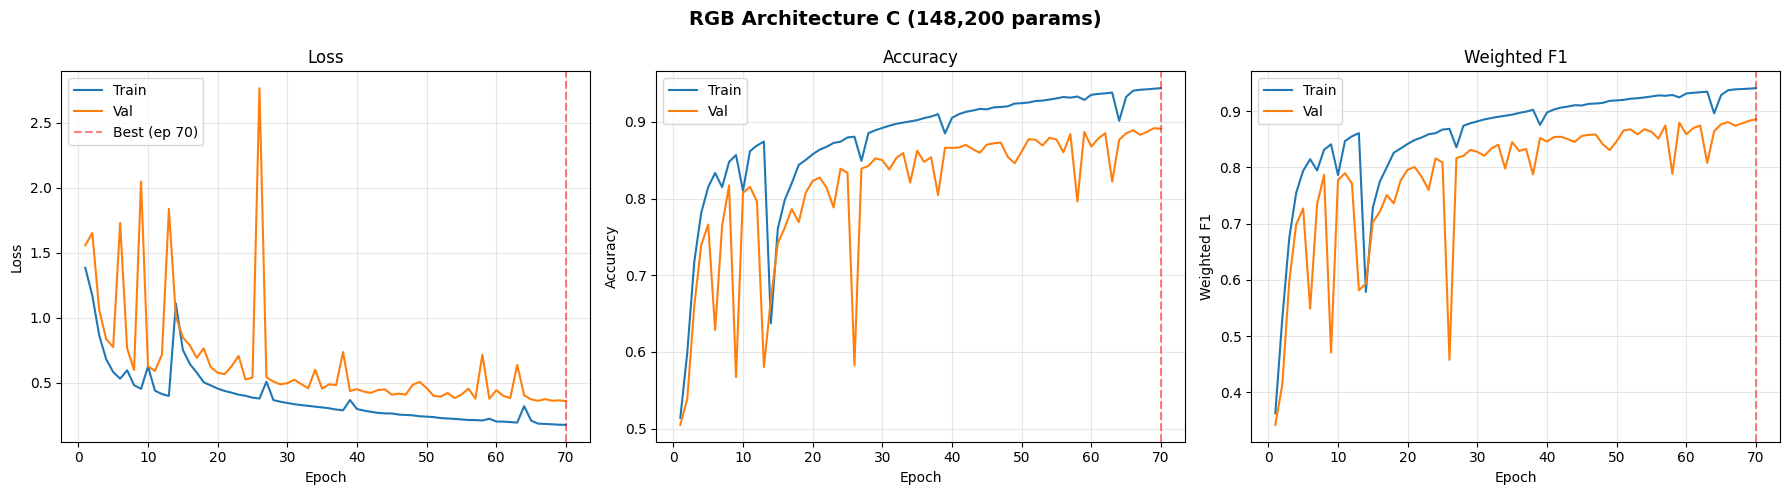

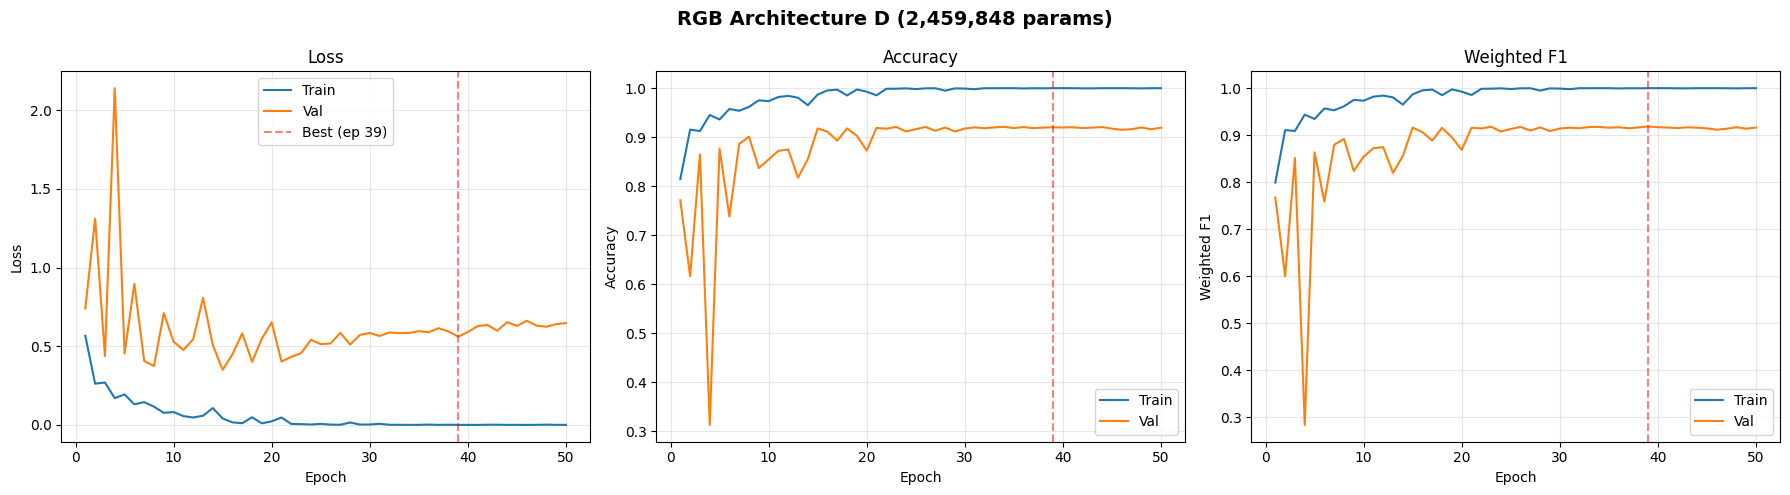

In [8]:
for arch in ["A", "B", "C", "D"]:
    plot_training_curves(
        histories[arch],
        title=f"{MODALITY} Architecture {arch} ({param_counts[arch]:,} params)",
        save_name=f"part1_{MODALITY.lower()}_arch{arch}_curves.png"
    )

## 8. Identify Optimal Architecture

In [9]:
best = max(results, key=lambda r: r["best_val_f1"])
print(f"\nOptimal {MODALITY} architecture: {best['label']}")
print(f"  Parameters: {best['param_count']:,}")
print(f"  Val Accuracy: {best['best_val_acc']:.4f}")
print(f"  Val F1: {best['best_val_f1']:.4f}")
print(f"  Best Epoch: {best['best_epoch']}")

# Identify model with modest overfitting (for Part 2)
print("\nOverfitting analysis (train - val gap):")
for r in results:
    gap_acc = r["best_train_acc"] - r["best_val_acc"]
    gap_f1 = r["best_train_f1"] - r["best_val_f1"]
    print(f"  {r['label']}: acc gap = {gap_acc:.4f}, F1 gap = {gap_f1:.4f}")


Optimal RGB architecture: Arch D
  Parameters: 2,459,848
  Val Accuracy: 0.9201
  Val F1: 0.9185
  Best Epoch: 39

Overfitting analysis (train - val gap):
  Arch A: acc gap = 0.0261, F1 gap = 0.0401
  Arch B: acc gap = 0.0435, F1 gap = 0.0566
  Arch C: acc gap = 0.0560, F1 gap = 0.0596
  Arch D: acc gap = 0.0798, F1 gap = 0.0814


---
**Next:** Use the architecture with modest overfitting for Part 2 regularization experiments.